In [1]:
library(pheatmap)
library(ComplexHeatmap)
library(data.table)
library(dplyr)
library(ggplot2)
library(circlize)



Warning message:
“package ‘pheatmap’ was built under R version 4.4.1”
Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.4.1”
Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))
! pheatmap() has been masked by ComplexHeatmap::pheatmap(). Most of the arguments
   in the original pheatmap() are identicall

In [4]:
source("~/Scripts/utils/load_gtf_cgc_dresden.R")
source("~/Scripts/ProteinExpression/load_pr_data.R")


In [5]:
create_fisher_dt <- function(aberrant_dt, expression_direction, gene_list, omics_type="PROTRIDER", cluster_col="Diag"){
  
  if (omics_type == "PROTRIDER"){
    omic_id <- "proteinID"
    zscore_col <- "zScore"
    outlier_col <- "aberrant"
  } else if(omics_type == "OUTRIDER" | omics_type == "Activation"){
    omic_id <- "geneID"
    zscore_col <- "zScore"
    outlier_col <- "aberrant"
  } else if (omics_type=="FRASER"){
      outlier_col <- "aberrant"
      omic_id <- "hgncSymbol"
  }
  
  aberrant_events_dt_filtered <- aberrant_dt[get(omic_id) %in% gene_list]
  if (expression_direction == "Underexpression"){
    aberrant_events_dt_filtered <- aberrant_events_dt_filtered[get(zscore_col) < 0]
  } else if(expression_direction == "Overexpression"){
    aberrant_events_dt_filtered <- aberrant_events_dt_filtered[get(zscore_col) > 0]
  }
  
  setnames(aberrant_events_dt_filtered, old = omic_id, new = "proteinID")  
  setnames(aberrant_events_dt_filtered, old = cluster_col, new = "cluster_column")  
  
  
  A_counts <- aberrant_events_dt_filtered[
    get(outlier_col) == TRUE,
    uniqueN(sampleID),
    by = c("proteinID", "cluster_column")
  ]
  setnames(A_counts, "V1", "A")
  # B: Samples without (aberrant) Gene G in Disease D
  # This is the total number of samples in a disease minus those with the aberrant gene.
  # First, get total unique samples per disease.
  total_samples_per_disease <- aberrant_events_dt_filtered[, uniqueN(sampleID), by = cluster_column]
  setnames(total_samples_per_disease, "V1", "TotalSamplesInDisease")
  
  # Create a full grid of all gene-disease combinations to ensure all B, C, D are covered
  all_gene_disease_combinations <- CJ(proteinID = unique(aberrant_events_dt_filtered[, proteinID]),
                                      cluster_column = unique(aberrant_events_dt_filtered$cluster_column))
  # Merge A_counts into the full grid
  plot_data <- merge(all_gene_disease_combinations, A_counts, by = c("proteinID", "cluster_column"), all.x = TRUE)
  plot_data[is.na(A), A := 0] # Set A to 0 if no aberrant samples found for that combo
  
  # Merge total samples per disease
  plot_data <- merge(plot_data, total_samples_per_disease, by = "cluster_column", all.x = TRUE)
  
  # Calculate B: Samples in Disease D that do NOT have aberrant Gene G
  plot_data[, B := TotalSamplesInDisease - A]
  # C: Samples with (aberrant) Gene G NOT in Disease D
  # We need total aberrant samples for each gene across ALL diseases first.
  total_aberrant_gene_counts <- aberrant_events_dt_filtered[
    get(outlier_col) == TRUE,
    .(TotalAberrantGeneOverall = uniqueN(sampleID)),
    by = "proteinID"
  ]
  # setnames(total_aberrant_gene_counts, "V1", "TotalAberrantGeneOverall")
  
  # Merge total_aberrant_gene_counts
  plot_data <- merge(plot_data, total_aberrant_gene_counts, by = "proteinID", all.x = TRUE)
  
  plot_data[, C := TotalAberrantGeneOverall - A]
  # D: Samples without (aberrant) Gene G NOT in Disease D
  # Total samples overall for each gene:
  total_samples_overall_per_gene <- aberrant_events_dt_filtered[
    ,
    .(TotalGeneSamplesOverall = uniqueN(sampleID)),
    by = "proteinID"
  ]
  # setnames(total_samples_overall_per_gene, "V1", "TotalGeneSamplesOverall")
  plot_data <- merge(plot_data, total_samples_overall_per_gene, by = "proteinID", all.x = TRUE)
  
  # Samples NOT in Disease D for a specific gene:
  # Total samples for that gene MINUS samples for that gene IN the current Disease_entity
  samples_not_in_disease_for_gene <- aberrant_events_dt_filtered[
    ,
    .(SamplesInDiseaseForGene = uniqueN(sampleID)),
    by = c("proteinID", "cluster_column")
  ]
  # setnames(samples_not_in_disease_for_gene, "V1", "SamplesInDiseaseForGene")
  plot_data <- merge(plot_data, samples_not_in_disease_for_gene, by = c("proteinID", "cluster_column"), all.x = TRUE)
  plot_data[is.na(SamplesInDiseaseForGene), SamplesInDiseaseForGene := 0]
  
  plot_data[, D := (TotalGeneSamplesOverall - SamplesInDiseaseForGene) - C]
  
  
  # --- 3. Calculate Odds Ratio ---
  epsilon <- 0.5 # For stable calculation with zero counts
  
  plot_data[, odds_ratio := {
    or_val = ((A + epsilon) / (B + epsilon)) / ((C + epsilon) / (D + epsilon))
    replace(or_val, is.infinite(or_val) | is.nan(or_val), NA) # Handle Inf/NaN
  }, by = .(proteinID, cluster_column)]
  
  # Cap odds ratio at 0 if less than 1, as per the plot's visual representation
  plot_data[odds_ratio < 1, odds_ratio := 0]
  
}

prepare_plot_data <- function(plot_data){
  
  # --- 4. Prepare data for plotting (categorize Odds Ratio) ---
  my_colors <- c(
    "1" = "#FFFFFF",        # White or very light grey for 1
    "1-10" = "#D9D1E8",     # Light purple for 1-10
    "10-100" = "#A38ECF",   # Medium purple for 10-100
    "100-1000" = "#6D4FB6", # Darker purple for 100-1000
    "ge1000" = "#441E7F"    # Darkest purple for >=1000
  )
  
  # Define breaks and labels for the legend
  or_breaks <- c(1, 10, 100, 1000, Inf)
  or_labels <- c("1-10", "10-100", "100-1000", "ge1000") # Exclude the '1' as a range start point
  
  plot_data[, odds_ratio_category := cut(odds_ratio,
                                         breaks = c(0, or_breaks), # Start from 0 to capture OR=1
                                         labels = c("1", or_labels),
                                         right = FALSE, # [lower, upper)
                                         include.lowest = TRUE)] # Include 1 in the "1" category
  
  plot_data$cluster_column <- factor(plot_data$cluster_column)
  plot_data$proteinID <- factor(plot_data$proteinID)
  
  # Filter out NA levels that might occur if some genes/diseases from the plot are not in your data
  plot_data <- plot_data[!is.na(cluster_column) & !is.na(proteinID)]
  
  
  
  
  odds_ratio_matrix <- as.data.table(dcast(plot_data, cluster_column ~ proteinID, value.var = "odds_ratio"))
  odds_ratio_matrix[is.na(odds_ratio_matrix)] <- 0
  
  # Set row names for the matrix (Disease_entity)
  odds_ratio_matrix_rownames <- odds_ratio_matrix$cluster_column
  
  odds_ratio_matrix[, cluster_column := NULL] # Remove the ID column
  odds_ratio_matrix <- as.matrix(odds_ratio_matrix)
  rownames(odds_ratio_matrix) <- odds_ratio_matrix_rownames
  return (odds_ratio_matrix)
  
}


In [6]:
or_res <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/protrider_summary.csv")
or_res[padjust <= 0.05, aberrant := TRUE]
or_res[, geneID:= sub("\\..*", "", geneID)]

rna_sa <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv")
or_res <- left_join(or_res,rna_sa[, c("pid", "Oncotree Code", "SEX", "ICD10 Code", "TISSUE", "Tumorzellgehalt (Bioinformatik)", "Diag")], by=c("sampleID" = "pid"))

or_res <- left_join(or_res, gene_annot_dt, by=c("geneID" = "geneID_short"))
setnames(or_res, "geneID", "geneID_short")
setnames(or_res, "gene_name", "geneID")

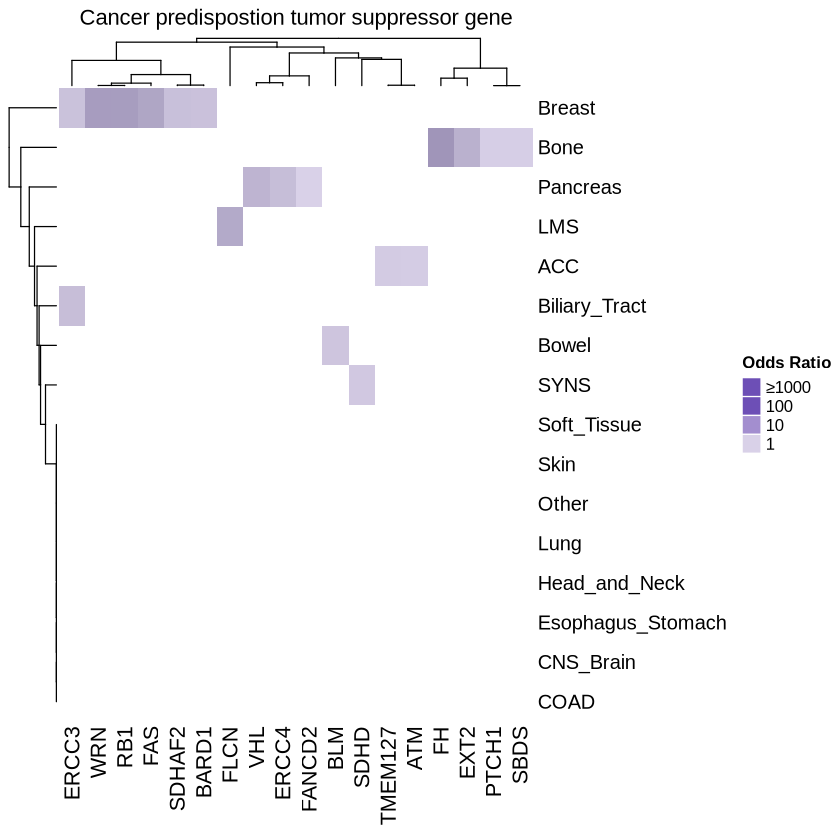

In [159]:
plot_data <- create_fisher_dt(or_res, "Underexpression", dresden_dt_tsg$gene_name, omics_type="OUTRIDER")
plot_data <- plot_data[TotalAberrantGeneOverall > 1]
odds_ratio_matrix <- prepare_plot_data(plot_data)
odds_ratio_matrix <- odds_ratio_matrix[, colSums(odds_ratio_matrix) != 0]
idx <- which(odds_ratio_matrix >= 1, arr.ind = TRUE)

or_dt <- data.table(
  row_name = rownames(odds_ratio_matrix)[idx[, "row"]],
  col_name = colnames(odds_ratio_matrix)[idx[, "col"]],
  odds_pr_overexpression = odds_ratio_matrix[idx]
)
or_dt[, gene_cancer := paste0(row_name, "_", col_name)]
or_dt <- or_dt[order(-odds_pr_overexpression)]
genes_of_interest <- union(or_dt[1:30, col_name], cgc_tsg$gene_name)

breaks <- c(0, 1, 10, 100, max(odds_ratio_matrix, na.rm = TRUE) + 1)
colors <- c("#FFFFFF", "#D9D1E8", "#A38ECF", "#6D4FB6", "#441E7F")
col_fun <- colorRamp2(breaks, colors, space = "RGB")
p_heatmap <-  Heatmap(
  odds_ratio_matrix,
  col = col_fun,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 90,
  name = "Odds Ratio",
  heatmap_legend_param = list(
    at = c(1, 10, 100, 1000),
    labels = c("1", "10", "100", "≥1000"),
    color_bar = "discrete",
    legend_direction = "horizontal"
  ),
  column_title = "Cancer predispostion tumor suppressor gene",
  column_names_gp = gpar(fontsize = 13)
)

# png(paste0("~/png.png") ,
#     width = 6, height = 6, units = "in", res = 600)
p_heatmap
# dev.off()

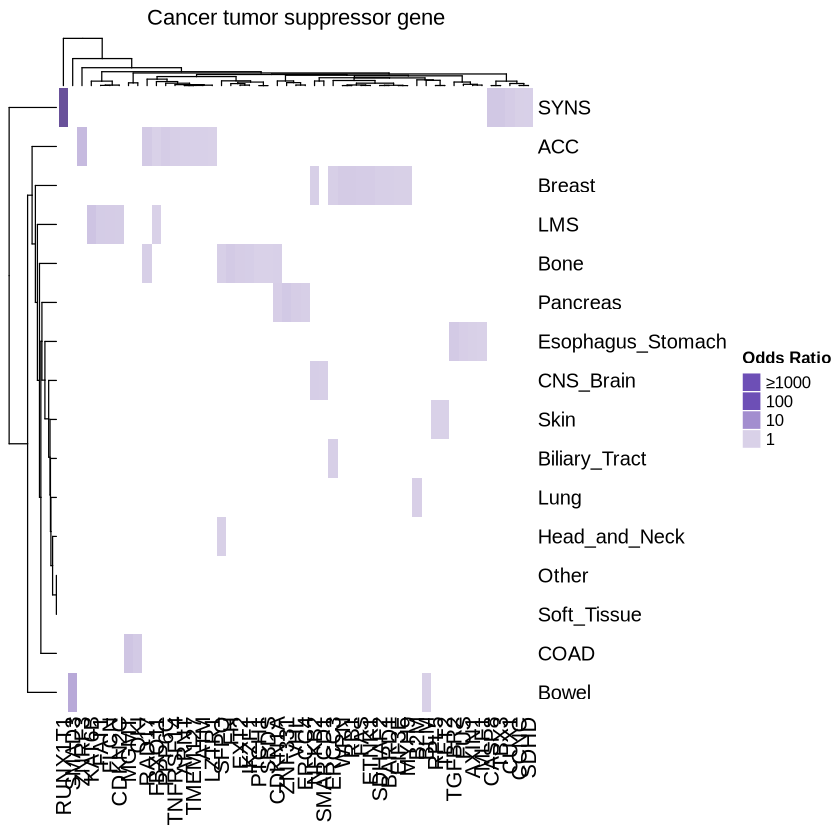

In [9]:
plot_data <- create_fisher_dt(or_res, "Underexpression", cgc_tsg$gene_name, omics_type="OUTRIDER")
plot_data <- plot_data[TotalAberrantGeneOverall > 1]
odds_ratio_matrix <- prepare_plot_data(plot_data)
odds_ratio_matrix <- odds_ratio_matrix[, colSums(odds_ratio_matrix) != 0]
idx <- which(odds_ratio_matrix >= 1, arr.ind = TRUE)

or_dt <- data.table(
  row_name = rownames(odds_ratio_matrix)[idx[, "row"]],
  col_name = colnames(odds_ratio_matrix)[idx[, "col"]],
  odds_pr_overexpression = odds_ratio_matrix[idx]
)
or_dt[, gene_cancer := paste0(row_name, "_", col_name)]
or_dt <- or_dt[order(-odds_pr_overexpression)]
genes_of_interest <- union(or_dt[1:30, col_name], cgc_tsg$gene_name)

breaks <- c(0, 1, 10, 100, max(odds_ratio_matrix, na.rm = TRUE) + 1)
colors <- c("#FFFFFF", "#D9D1E8", "#A38ECF", "#6D4FB6", "#441E7F")
col_fun <- colorRamp2(breaks, colors, space = "RGB")
p_heatmap <-  Heatmap(
  odds_ratio_matrix,
  col = col_fun,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 90,
  name = "Odds Ratio",
  heatmap_legend_param = list(
    at = c(1, 10, 100, 1000),
    labels = c("1", "10", "100", "≥1000"),
    color_bar = "discrete",
    legend_direction = "horizontal"
  ),
  column_title = "Cancer tumor suppressor gene",
  column_names_gp = gpar(fontsize = 13)
)

# png(paste0("~/png.png") ,
#     width = 6, height = 6, units = "in", res = 600)
p_heatmap
# dev.off()

In [156]:
length(dresden_dt_oncogene$gene_name)

[1] 32

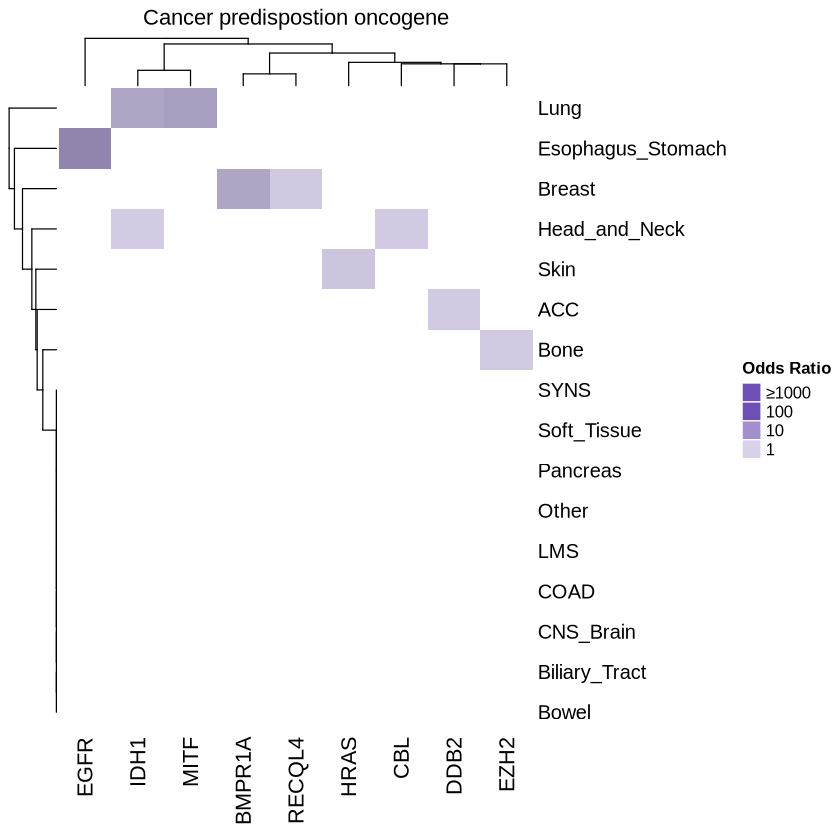

In [158]:
plot_data <- create_fisher_dt(or_res, "Overexpression", dresden_dt_oncogene$gene_name, omics_type="OUTRIDER")
plot_data <- plot_data[TotalAberrantGeneOverall > 1]
odds_ratio_matrix <- prepare_plot_data(plot_data)
odds_ratio_matrix <- odds_ratio_matrix[, colSums(odds_ratio_matrix) != 0]
idx <- which(odds_ratio_matrix >= 1, arr.ind = TRUE)

or_dt <- data.table(
  row_name = rownames(odds_ratio_matrix)[idx[, "row"]],
  col_name = colnames(odds_ratio_matrix)[idx[, "col"]],
  odds_pr_overexpression = odds_ratio_matrix[idx]
)
or_dt[, gene_cancer := paste0(row_name, "_", col_name)]
or_dt <- or_dt[order(-odds_pr_overexpression)]
genes_of_interest <- union(or_dt[1:30, col_name], cgc_tsg$gene_name)

breaks <- c(0, 1, 10, 100, max(odds_ratio_matrix, na.rm = TRUE) + 1)
colors <- c("#FFFFFF", "#D9D1E8", "#A38ECF", "#6D4FB6", "#441E7F")
col_fun <- colorRamp2(breaks, colors, space = "RGB")
p_heatmap <-  Heatmap(
  odds_ratio_matrix,
  col = col_fun,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 90,
  name = "Odds Ratio",
  heatmap_legend_param = list(
    at = c(1, 10, 100, 1000),
    labels = c("1", "10", "100", "≥1000"),
    color_bar = "discrete",
    legend_direction = "horizontal"
  ),
  column_title = "Cancer predispostion oncogene",
  column_names_gp = gpar(fontsize = 13)
)

# png(paste0("~/png1.png") ,
#     width = 10, height = 6, units = "in", res = 600)
p_heatmap
# dev.off()

In [138]:
pr_output_name <- "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"
pr_res_all <-load_pr_data(paste0("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_", pr_output_name, "/protrider_summary.csv"))
pr_res_all[, geneID := gene_id]



Warning message in `[.data.table`(pr_res, , `:=`("geneID", geneID_short)):
“Invalid .internal.selfref detected and fixed by taking a (shallow) copy of the data.table so that := can add this new column by reference. At an earlier point, this data.table has been copied by R (or was created manually using structure() or similar). Avoid names<- and attr<- which in R currently (and oddly) may copy the whole data.table. Use set* syntax instead to avoid copying: ?set, ?setnames and ?setattr. If this message doesn't help, please report your use case to the data.table issue tracker so the root cause can be fixed or this message improved.”


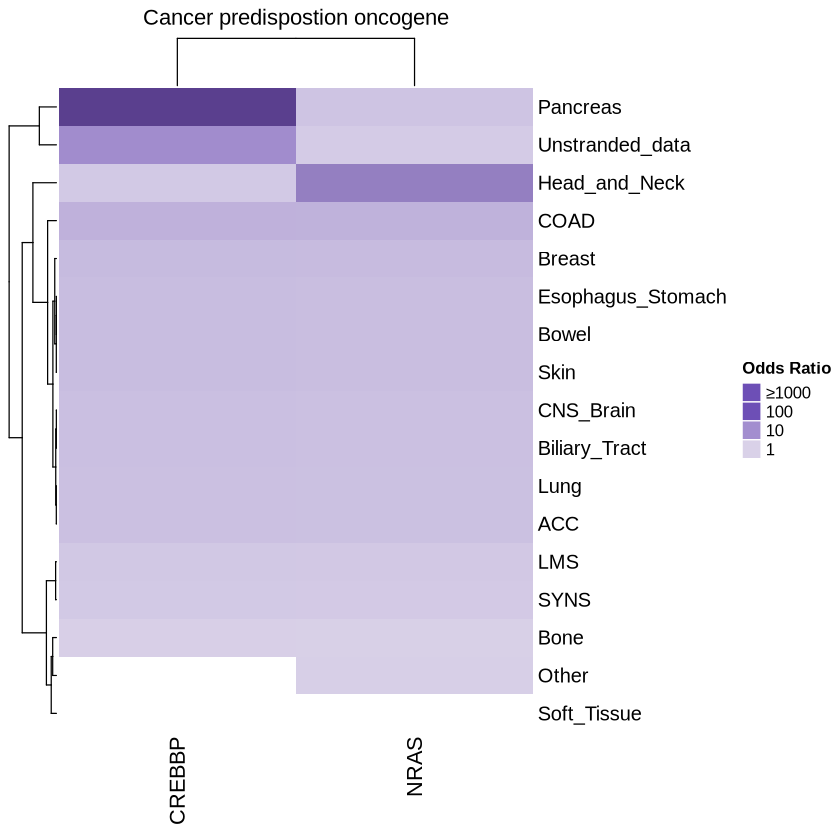

In [160]:
plot_data <- create_fisher_dt(pr_res_all, "Overexpression", dresden_dt_oncogene$gene_name, omics_type="PROTRIDER")
plot_data <- plot_data[TotalAberrantGeneOverall > 1]
odds_ratio_matrix <- prepare_plot_data(plot_data)
odds_ratio_matrix <- odds_ratio_matrix[, colSums(odds_ratio_matrix) != 0]
idx <- which(odds_ratio_matrix >= 1, arr.ind = TRUE)
or_dt <- data.table(
  row_name = rownames(odds_ratio_matrix)[idx[, "row"]],
  col_name = colnames(odds_ratio_matrix)[idx[, "col"]],
  odds_pr_overexpression = odds_ratio_matrix[idx]
)
or_dt[, gene_cancer := paste0(row_name, "_", col_name)]
or_dt <- or_dt[order(-odds_pr_overexpression)]
genes_of_interest <- union(or_dt[1:30, col_name], cgc_tsg$gene_name)

breaks <- c(0, 1, 10, 100, max(odds_ratio_matrix, na.rm = TRUE) + 1)
colors <- c("#FFFFFF", "#D9D1E8", "#A38ECF", "#6D4FB6", "#441E7F")
col_fun <- colorRamp2(breaks, colors, space = "RGB")
p_heatmap <-  Heatmap(
  odds_ratio_matrix,
  col = col_fun,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 90,
  name = "Odds Ratio",
  heatmap_legend_param = list(
    at = c(1, 10, 100, 1000),
    labels = c("1", "10", "100", "≥1000"),
    color_bar = "discrete",
    legend_direction = "horizontal"
  ),
  column_title = "Cancer predispostion oncogene",
  column_names_gp = gpar(fontsize = 13)
)


p_heatmap


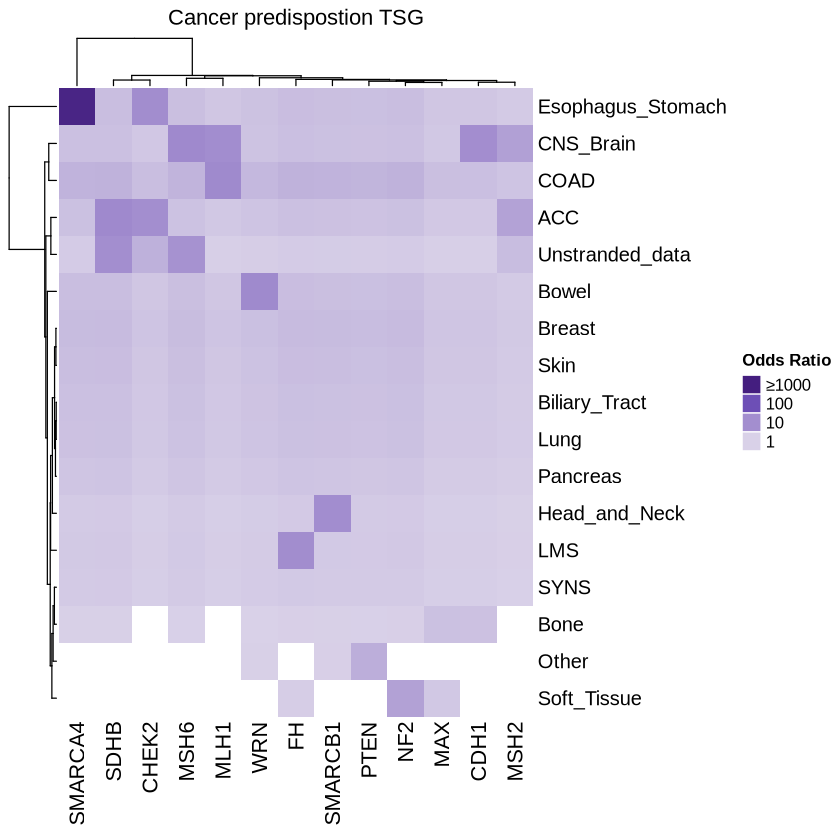

In [162]:
plot_data <- create_fisher_dt(pr_res_all, "Underexpression", dresden_dt_tsg$gene_name, omics_type="PROTRIDER")
plot_data <- plot_data[TotalAberrantGeneOverall > 1]
odds_ratio_matrix <- prepare_plot_data(plot_data)
odds_ratio_matrix <- odds_ratio_matrix[, colSums(odds_ratio_matrix) != 0]
idx <- which(odds_ratio_matrix >= 1, arr.ind = TRUE)

or_dt <- data.table(
  row_name = rownames(odds_ratio_matrix)[idx[, "row"]],
  col_name = colnames(odds_ratio_matrix)[idx[, "col"]],
  odds_pr_overexpression = odds_ratio_matrix[idx]
)
or_dt[, gene_cancer := paste0(row_name, "_", col_name)]
or_dt <- or_dt[order(-odds_pr_overexpression)]
genes_of_interest <- union(or_dt[1:30, col_name], cgc_tsg$gene_name)

breaks <- c(0, 1, 10, 100, max(odds_ratio_matrix, na.rm = TRUE) + 1)
colors <- c("#FFFFFF", "#D9D1E8", "#A38ECF", "#6D4FB6", "#441E7F")
col_fun <- colorRamp2(breaks, colors, space = "RGB")
p_heatmap <-  Heatmap(
  odds_ratio_matrix,
  col = col_fun,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 90,
  name = "Odds Ratio",
  heatmap_legend_param = list(
    at = c(1, 10, 100, 1000),
    labels = c("1", "10", "100", "≥1000"),
    color_bar = "discrete",
    legend_direction = "horizontal"
  ),
  column_title = "Cancer predispostion TSG",
  column_names_gp = gpar(fontsize = 13)
)


p_heatmap


In [166]:
fr_res_junc <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_results_gene_all.tsv")

In [180]:
fr_res_junc[, aberrant := FALSE]
fr_res_junc[padjust <= 0.05 & abs(deltaPsi) >= 0.1, aberrant := TRUE]


In [186]:
colnames(fr_res_junc)

[1] "seqnames"                      "start"                        
 [3] "end"                           "width"                        
 [5] "strand"                        "sampleID"                     
 [7] "hgncSymbol"                    "type"                         
 [9] "pValue"                        "padjust"                      
[11] "psiValue"                      "deltaPsi"                     
[13] "counts"                        "totalCounts"                  
[15] "meanCounts"                    "meanTotalCounts"              
[17] "nonsplitCounts"                "nonsplitProportion"           
[19] "nonsplitProportion_99quantile" "annotatedJunction"            
[21] "pValueGene"                    "padjustGene"                  
[23] "Diag"                          "aberrant"

In [192]:
plot_data <- create_fisher_dt(fr_res_junc, "Splicing", dresden_dt_tsg$gene_name, omics_type="FRASER")
plot_data <- plot_data[TotalAberrantGeneOverall > 1]
odds_ratio_matrix <- prepare_plot_data(plot_data)
odds_ratio_matrix <- odds_ratio_matrix[, colSums(odds_ratio_matrix) != 0]
idx <- which(odds_ratio_matrix >= 1, arr.ind = TRUE)

or_dt <- data.table(
  row_name = rownames(odds_ratio_matrix)[idx[, "row"]],
  col_name = colnames(odds_ratio_matrix)[idx[, "col"]],
  odds_pr_overexpression = odds_ratio_matrix[idx]
)
or_dt[, gene_cancer := paste0(row_name, "_", col_name)]
or_dt <- or_dt[order(-odds_pr_overexpression)]
genes_of_interest <- union(or_dt[1:30, col_name], cgc_tsg$gene_name)

breaks <- c(0, 1, 10, 100, max(odds_ratio_matrix, na.rm = TRUE) + 1)
colors <- c("#FFFFFF", "#D9D1E8", "#A38ECF", "#6D4FB6", "#441E7F")
col_fun <- colorRamp2(breaks, colors, space = "RGB")
p_heatmap <-  Heatmap(
  odds_ratio_matrix,
  col = col_fun,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 90,
  name = "Odds Ratio",
  heatmap_legend_param = list(
    at = c(1, 10, 100, 1000),
    labels = c("1", "10", "100", "≥1000"),
    color_bar = "discrete",
    legend_direction = "horizontal"
  ),
  column_title = "Cancer predispostion TSG",
  column_names_gp = gpar(fontsize = 8)
)

png(paste0("~/frasr.png") ,
    width = 10, height = 6, units = "in", res = 600)
p_heatmap
dev.off()

pdf 
  2

In [203]:
mu <- 5
theta <-100
activation_res <- fread(paste0("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/nb_act/activation_res_protein_coding_genes_sig_theta", theta, "_mu", mu, "_BH.tsv"))



rna_sa <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv")
activation_res <- left_join(activation_res,rna_sa[, c("pid", "Oncotree Code", "SEX", "ICD10 Code", "TISSUE", "Tumorzellgehalt (Bioinformatik)")], by=c("sampleID" = "pid"))

activation_res <- left_join(activation_res, gene_annot_dt, by=c("geneID" = "gene_id"))
setnames(activation_res, "geneID", "geneID_long")
setnames(activation_res, "gene_name", "geneID")
activation_res[, Diag := DROP_GROUP]
activation_res[, aberrant := TRUE]


plot_data <- create_fisher_dt(activation_res, "Activation", cgc_oncogene$gene_name, omics_type="OUTRIDER")
odds_ratio_matrix <- prepare_plot_data(plot_data)

Warning message in `[.data.table`(activation_res, , `:=`(Diag, DROP_GROUP)):
“Invalid .internal.selfref detected and fixed by taking a (shallow) copy of the data.table so that := can add this new column by reference. At an earlier point, this data.table has been copied by R (or was created manually using structure() or similar). Avoid names<- and attr<- which in R currently (and oddly) may copy the whole data.table. Use set* syntax instead to avoid copying: ?set, ?setnames and ?setattr. If this message doesn't help, please report your use case to the data.table issue tracker so the root cause can be fixed or this message improved.”


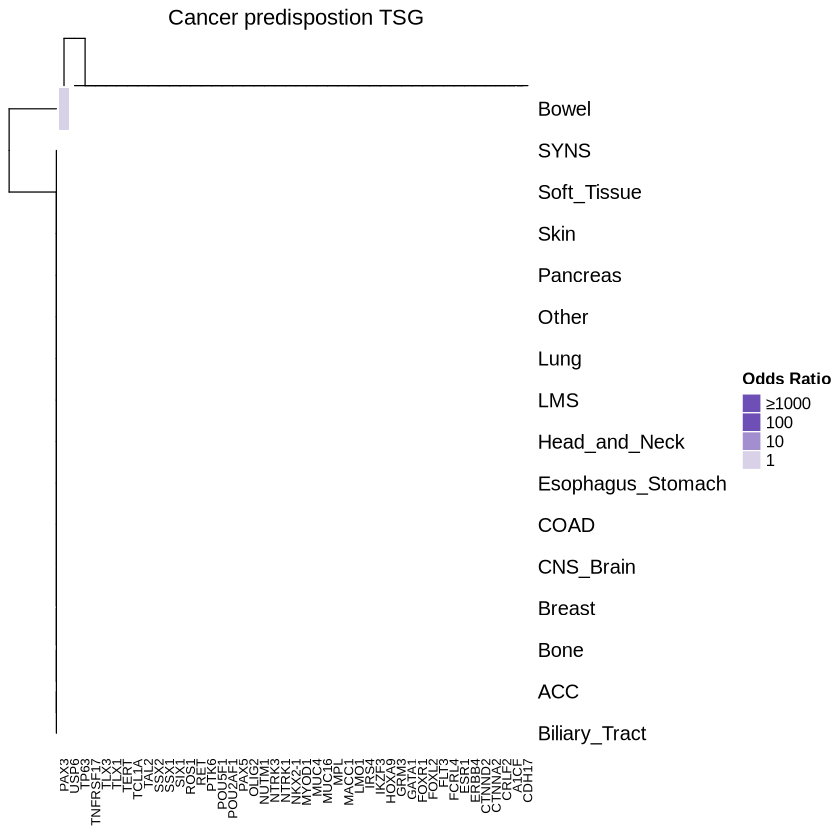

In [204]:
idx <- which(odds_ratio_matrix >= 1, arr.ind = TRUE)

or_dt <- data.table(
  row_name = rownames(odds_ratio_matrix)[idx[, "row"]],
  col_name = colnames(odds_ratio_matrix)[idx[, "col"]],
  odds_pr_overexpression = odds_ratio_matrix[idx]
)
or_dt[, gene_cancer := paste0(row_name, "_", col_name)]
or_dt <- or_dt[order(-odds_pr_overexpression)]
genes_of_interest <- union(or_dt[1:30, col_name], cgc_tsg$gene_name)

breaks <- c(0, 1, 10, 100, max(odds_ratio_matrix, na.rm = TRUE) + 1)
colors <- c("#FFFFFF", "#D9D1E8", "#A38ECF", "#6D4FB6", "#441E7F")
col_fun <- colorRamp2(breaks, colors, space = "RGB")
p_heatmap <-  Heatmap(
  odds_ratio_matrix,
  col = col_fun,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 90,
  name = "Odds Ratio",
  heatmap_legend_param = list(
    at = c(1, 10, 100, 1000),
    labels = c("1", "10", "100", "≥1000"),
    color_bar = "discrete",
    legend_direction = "horizontal"
  ),
  column_title = "Cancer predispostion TSG",
  column_names_gp = gpar(fontsize = 8)
)
p_heatmap
